In [23]:
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
%matplotlib inline
import numpy as np
from numpy import linalg as LA
from scipy import linalg
from scipy import stats
from pylab import * 
from mpl_toolkits.axes_grid1 import ImageGrid
#from pylab import rcParams
#from tempfile import TemporaryFile
P = open("/cueva/Susana/Susana_josePC/Prices.txt","rb")
S = open("/cueva/Susana/Susana_josePC/Symbols.txt","r")
D = open("/cueva/Susana/Susana_josePC/Dates.txt","r")
G = open("/cueva/Susana/Susana_josePC/Gics.txt","r")
from __future__ import division 


In [3]:
s=[]
lines=S.readlines()
S.close()
for line in lines:
	values = line.split()
	s.append(values[0])
lensymbols=len(s)

d=[]
lines=D.readlines()
D.close() 
for line in lines:
	values = line.split()
	d.append(values[0])
#print type(values)	
lendates=len(d)

g=[]
lines=G.readlines()
G.close()
for line in lines:
	values = line.split()
	g.append(values[0])
    
Prices=np.loadtxt("Prices.txt")      
lenPrices=len(Prices)

In [4]:
def remove_cruft(s):
    return s[:-3]

In [5]:
gicname=[]
gicname=g[:]
for i in xrange(293):
    gicname[i]=gicname[i].replace("10","E")
    gicname[i]=gicname[i].replace("15","M")
    gicname[i]=gicname[i].replace("20","I")
    gicname[i]=gicname[i].replace("25","CD")
    gicname[i]=gicname[i].replace("30","CS")
    gicname[i]=gicname[i].replace("35","HC")
    gicname[i]=gicname[i].replace("40","F")
    gicname[i]=gicname[i].replace("45","IT")
    gicname[i]=gicname[i].replace("50","TS")
    gicname[i]=gicname[i].replace("55","U")


In [6]:
#----- Rendimientos---

Returns=[]

for i in range(lensymbols):
	Returns.append([])
	for j in range(1,lendates):
		r=(Prices[i][j-1]/Prices[i][j])-1
                Returns[-1].append(r)
Returns=np.asarray(Returns)
#print len(Returns)

In [7]:
qs=[.05,.1,.15,.2,.5]

In [8]:
def PR_funtion(vt):
    vPR=np.sum(vt**4,axis=0)
    vPR=1/vPR
    return vPR

In [9]:
def spectr_contrib(v1t,vt,n,t):
    #que tanto contribuye el espectro original con los evectores de PM
    suma=[]
    for i in xrange(n):
        sumvv=0
        for j in xrange(n-t+1,n):
            v1v=np.dot(v1t[:,i],vt[:,j])
            sumvv+=(v1v)**2  
        suma.append(sumvv)    
    return suma

In [7]:
for i in xrange(262):
    fecha=d[i*22]
    num=i
    #vectors=np.loadtxt("evector%d.dat"%num)
    #---------------
    #PR
    #vPR=PR_funtion(vectors)
    #plt.plot(vPR)
    #titulo="/cueva/Susana/SusanaDos/PR2-S&P500/PR%d.png"%num
    #plt.ylabel("$PR(V^j)$",fontsize=14)
    #plt.xlabel("$V^j$",fontsize=14)
    #plt.title("%s" %fecha,fontsize=16)
    #savefig(titulo, bbox_inches='tight')
    #plt.clf()
    #plt.close()
    for qi in qs:
        e=qi
        q=1+e
        nombre="evectorPM%dq%.2f.dat"%(num,q)
        PMvectors=np.loadtxt(nombre)
     
        #------------------------
        #PR para vector con PM
        
        PMvPR=PR_funtion(PMvectors)
        plt.plot(PMvPR)
        titulo="/cueva/Susana/SusanaDos/PR2-S&P500/PR-PM%dq%.2f.png"%(num,q)
        plt.ylabel("$PR(VP^j)$",fontsize=14)
        plt.xlabel("$Vp^j$",fontsize=14)
        plt.title("%s" %fecha,fontsize=16)
        savefig(titulo, bbox_inches='tight')
        plt.clf()
        plt.close()
        

NameError: name 'qs' is not defined

In [8]:
def spectr_contrib(v1t,vt,n,t):
    #que tanto contribuye el espectro original con los evectores de PM
    suma=[]
    for i in xrange(n):
        sumvv=0
        for j in xrange(n-t+1,n):
            v1v=np.dot(v1t[:,i],vt[:,j])
            sumvv+=(v1v)**2  
        suma.append(sumvv)    
    return suma

In [9]:
# hace OSC y guarda la fig para todas las matrices
T=44
N=293
for i in xrange(261):
    fecha=d[i*22]
    num=i
    vectors=np.loadtxt("evector%d.dat"%num)
    for qi in qs:
        e=qi
        q=1+e
        nombre="evectorPM%dq%.2f.dat"%(num,q)
        PMvectors=np.loadtxt(nombre)
        OSC=spectr_contrib(PMvectors,vectors,N,T)
        plt.semilogy(OSC[:])
        titulo="/cueva/Susana/SusanaDos/OSC-S&P500/OSC%d-q=%.2f.png" %(num,q)
        plt.xlabel("$VP^j$",fontsize=14)
        plt.ylabel("$OSC(VP^j)$",fontsize=14)
        plt.title("%s" %fecha,fontsize=16)
        savefig(titulo, bbox_inches='tight')
        plt.clf()
        plt.close()

KeyboardInterrupt: 

In [12]:
#sumando OSC para los evectores del espectro emergente de cada matriz sin traslapar fechas
T=44
N=293
sumaOSC=[]
qi=.05
for i in xrange(0,261,2):
    fecha=d[22+i*22]
    num=i
    vectors=np.loadtxt("evector%d.dat"%num)

    suma=0
    e=qi
    q=1+e
    nombre="evectorPM%dq%.2f.dat"%(num,q)
    PMvectors=np.loadtxt(nombre)
    OSC=spectr_contrib(PMvectors,vectors,N,T)
    OSCnp=np.array(OSC)
    suma=np.sum(OSCnp[:N-T+1])
    sumaOSC.append(suma)    

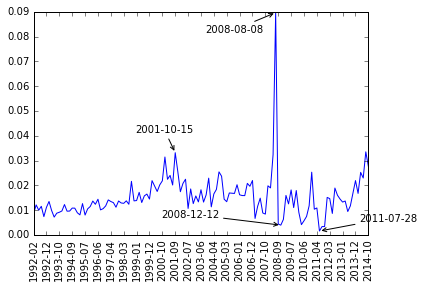

In [13]:
num=5
indice = np.arange(0,261,num)
fecha=d[::44]
fechalabel=fecha[::num]
plt.xticks(indice[:],[remove_cruft(s) for s in fechalabel], rotation = 90)
dia=d[22+(222*22)]

dia2=d[22+(188*22)]
dia3=d[22+(96*2*22)]
dia4=d[22+(55*2*22)]
#plt.xlim(0,132)
plt.annotate(dia, xy=(111, 0.00156909582159), xycoords='data',xytext=(40, 10), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia3, xy=(96,0.00394500857106), xycoords='data',xytext=(-120, 8), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia2, xy=(94.0, 0.0896390465299), xycoords='data',xytext=(-70, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia4, xy=(55, 0.0331581767059), xycoords='data',xytext=(-40, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.plot(sumaOSC[:]);

In [81]:
for i in xrange(0,261,2):
    if sumaOSC[i] > 0.033:
        print i/2, sumaOSC[i]

#print  sumaOSC[188]

55.0 0.0331581767059
94.0 0.0896390465299
129.0 0.0335055050871


In [62]:
for i in xrange(0,261,2):
    if sumaOSC[i] < 0.004:
        print i/2, sumaOSC[i]

#print  sumaOSC[188]

96.0 0.00394500857106
111.0 0.00156909582159
112.0 0.00337067707904
113.0 0.00335760596555


In [123]:
print d[22+(188*22)], sumaOSC[109]

2008-08-08 0.0596593075171


In [13]:
N=293
T=44
fecha=d[i*22]
num=i
vectors=np.loadtxt("evector%d.dat"%num)
for qi in qs:
        e=qi
        q=1+e
        nombre="/cueva/Susana/Susana_josePC/evector%d.dat"%num
        PMvectors=np.loadtxt(nombre)
        OSC=spectr_contrib(PMvectors,vectors,N,T)
        plt.semilogy(OSC[:])
        titulo="/cueva/Susana/SusanaDos/OSC-S&P500/OSC%d-q=%.2f.png" %(num,q)
        plt.xlabel("$VP^j$",fontsize=14)
        plt.ylabel("$OSC(VP^j)$",fontsize=14)
        plt.title("%s" %fecha,fontsize=16)
        savefig(titulo, bbox_inches='tight')
        plt.clf()
        plt.close()

In [15]:
#restando de los primeros 70 evectores de OSC el el osc de una fecha mas aleatoria
#luego sacar promedio y desviasion estandar para cada fecha
T=44
N=293
q=1.05
listapromedio=[]
liststd=[]
vector1=np.loadtxt("evector22.dat")
nombre1="evectorPM22q%.2f.dat"%q
PMvector1=np.loadtxt(nombre1)
OSC1=spectr_contrib(PMvector1,vector1,N,T)
OSC1=np.asarray(OSC1)

for i in xrange(0,262,2):
    num=i
    
    vector2=np.loadtxt("evector%d.dat"%num)
    
    nombre2="evectorPM%dq%.2f.dat"%(num,q)
    #PMvector1=np.loadtxt(nombre1)
    PMvector2=np.loadtxt(nombre2)
    
    OSC2=spectr_contrib(PMvector2,vector2,N,T)
    
    OSC2=np.asarray(OSC2)
    resta=np.subtract(OSC2[:70],OSC1[:70])
    promedio=np.mean(resta)
    destandar=np.std(resta)
    listapromedio.append(promedio)             
    liststd.append(destandar)
    #o1=plt.plot(OSC1[:60])
    #o2=plt.plot(OSC2[:60])


In [16]:
Cmean=[]
CPmean=[]
for i in range(0,262,2):
    fecha=d[i]
    C=np.loadtxt("MatrizCorr%d.dat"%i)
    CP=np.loadtxt("/cueva/Susana/SusanaDos/SyP-q1.05/MatrizCorrPM%dq1.05.dat"%i)
    cm=C.std()#desviacion estandar - No es el promedio
    cpm=CP.std()
    Cmean.append(cm)
    CPmean.append(cpm)

In [17]:
CPmeanprom=np.asarray(CPmean)
meanCm=np.mean(CPmeanprom)
Cnormal=(CPmeanprom-meanCm)/np.std(CPmeanprom)

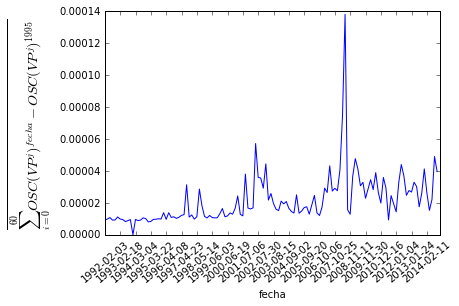

In [36]:
#la desviacion estandar de la resta de OSC
num=6
#indice = np.arange(0,132)
indice = np.arange(0,132,num)
fecha=d[0::44]
fechalabel=fecha[:132:num]
#fechalabel=fecha[0:132]
plt.xticks(indice,fechalabel, rotation =40)
plt.xlim(0,len(liststd))
fig=plt.plot(liststd)
plt.ylabel(r"$\overline {\sum_{i=0}^{60} OSC(VP^j)^{fecha} - OSC(VP^j)^{1995}}$", fontsize=14)
plt.xlabel("fecha")

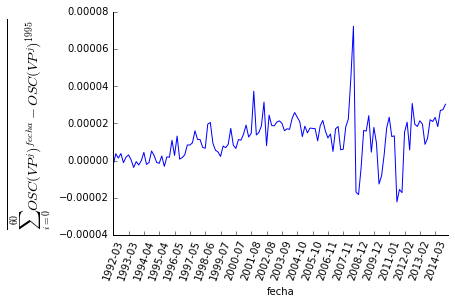

In [64]:
num=6
fig, ax = plt.subplots()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

#indice = np.arange(0,132)
indice = np.arange(0,132,num)
fecha=d[22::44]
fechalabel=fecha[:132:num]
#fechalabel=fecha[0:132]
plt.xticks(indice,[remove_cruft(s) for s in fechalabel], rotation =70)
plt.xlim(0,len(listapromedio))
fig=plt.plot(listapromedio)
plt.ylabel(r"$\overline {\sum_{i=0}^{60} OSC(VP^j)^{fecha} - OSC(VP^j)^{1995}}$", fontsize=14)
plt.xlabel("fecha")
#a2=plt.axhline(y=1.61947790362e-05,xmin=0,xmax=261,c="red",linewidth=0.5,zorder=0)
#rcParams['figure.figsize'] = 35,5

In [53]:
fechalabel[0]

'1992-02-03'

In [97]:
print listapromedio[23],fecha[11]

1.4089963695e-05 1994-02-01


In [30]:
lisprom=np.asarray(listapromedio)
meanlp=np.mean(lisprom)
normal=(lisprom-meanlp)/np.std(lisprom)

In [20]:
mSElist=[]
for i in xrange(0,262,2):
    fecha=d[(i*22)]    
    ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%i)
    m1=np.std(ww[:250])
    mSElist.append(m1)


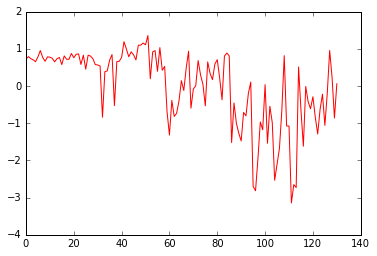

In [37]:
mSEmean=np.asarray(mSElist)
#plt.plot(mSEmean,color="red")
meanSE=np.mean(mSEmean)
mSEmean=(mSEmean-meanSE)/np.std(mSEmean)
plt.plot(mSEmean,color="red")

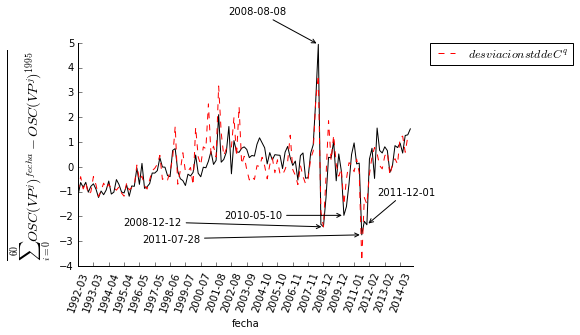

In [106]:
fig, ax = plt.subplots()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
plt.plot(normal, color="black")
num=6
#plt.plot(mSEmean,color="red")#promedio de los evalores del espectro emergente
indice = np.arange(0,132,num)
fecha=d[22::44]
fechalabel=fecha[0:132:num]
plt.xticks(indice,[remove_cruft(s) for s in fechalabel], rotation =70);
plt.xlim(0,len(normal))
#inforecuadro=r"$desviacion std de la matriz C$"
plt.plot(Cnormal,label=r"$desviacion std de C^q$", linestyle="--", color="red")
plt.ylabel(r"$\overline {\sum_{i=0}^{60} OSC(VP^j)^{fecha} - OSC(VP^j)^{1995}}$", fontsize=14)
plt.xlabel("fecha")
dia=fecha[94]
dia2=fecha[104]
dia3=fecha[111]
dia4=fecha[113]
dia5=fecha[96]
plt.annotate(dia3, xy=(111, -2.74224698868), xycoords='data',xytext=(-220, -7), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia2, xy=(104, -1.95683516392), xycoords='data',xytext=(-120, -3), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia4, xy=(113, -2.33752383648), xycoords='data',xytext=(10, 30),textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia, xy=(94, 4.9382215099), xycoords='data',xytext=(-90, 30), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia5, xy=(96, -2.41970183389), xycoords='data',xytext=(-200, 2), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);


In [66]:
for i in xrange(131):
    if normal[i]<-1.5:
        print i, normal[i]

95 -2.31804217045
96 -2.41970183389
104 -1.95683516392
105 -1.60408599464
111 -2.74224698868
112 -2.19633059884
113 -2.33752383648


In [65]:
for i in xrange(131):
    if normal[i]>4:
        print i, normal[i]

94 4.9382215099


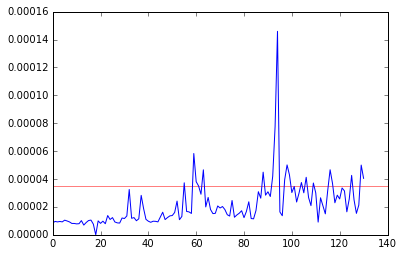

In [83]:
plt.plot(liststd)

a2=plt.axhline(y=0.000035,xmin=0,xmax=261,c="red",linewidth=0.5,zorder=0)

In [8]:
for i in xrange(261):
    if .000035<liststd[i]<.00004:
        print liststd.index(liststd[i])

109
110
120
122
123
127
185
194
195
199
208
211
218
221
233
234
239
241
243


In [ ]:
a1=plt.plot(listapromedio)

a2=plt.axhline(y=0.00005,xmin=0,xmax=261,c="red",linewidth=0.5,zorder=0)

In [66]:
for i in xrange(131):
    if listapromedio[i]>=.000035:
        print (listapromedio.index(listapromedio[i]))*2


110
118
186
188
234
258
260


In [65]:
for i in xrange(131):
    if listapromedio[i]<=-1.61947790362e-05:
        print (listapromedio.index(listapromedio[i]))*2

222


-1.74061974213e-05 [  1.19714256e-05   1.13188948e-05  -3.16080708e-06   3.24031787e-06
  -2.74567408e-06  -5.35732654e-06  -1.17606456e-05  -1.62757399e-05
  -3.11941573e-05  -8.28231838e-06  -1.56318790e-05  -1.98312364e-05
  -1.87454914e-05  -1.64705255e-05  -1.80042622e-05  -1.55057847e-05
  -9.97212392e-06  -1.75656947e-05  -1.67578256e-05  -1.31675974e-05
  -1.53293470e-05  -1.20157943e-05  -1.43214269e-05  -1.98587029e-05
  -2.50891445e-05  -1.62937704e-05  -1.95054107e-05  -1.58783010e-05
  -3.52856074e-05  -1.29033981e-05  -1.93294876e-05  -2.25497327e-05
  -2.27178996e-05  -2.82553299e-05  -1.67403487e-05  -2.18245626e-05
  -1.58702145e-05  -2.57400791e-05  -2.04417155e-05  -1.21974426e-05
  -1.53625238e-05  -1.61274073e-05  -2.05691674e-05  -2.41209993e-05
  -2.60093742e-05  -1.57426545e-05  -3.04019663e-05  -3.35262665e-05
  -2.25783469e-05  -1.61334766e-05  -3.07043047e-05  -1.40521368e-05
  -1.93283089e-05  -1.75276956e-05  -2.30944592e-05  -1.84337568e-05
  -2.20020840e-

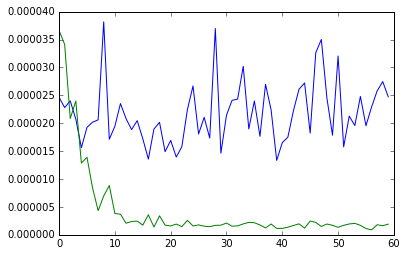

In [37]:

N=293
q=1.05
vector1=np.loadtxt("evector36.dat")
vector2=np.loadtxt("evector191.dat")
nombre1="evectorPM36q%.2f.dat"%q
nombre2="evectorPM191q%.2f.dat"%q
PMvector1=np.loadtxt(nombre1)
PMvector2=np.loadtxt(nombre2)
OSC1=spectr_contrib(PMvector1,vector1,N,T)
OSC2=spectr_contrib(PMvector2,vector2,N,T)
OSC1=np.asarray(OSC1)
OSC2=np.asarray(OSC2)
resta=np.subtract(OSC2[:60],OSC1[:60])
promedio=np.mean(resta)
print promedio, resta
o1=plt.plot(OSC1[:60])
o2=plt.plot(OSC2[:60])

In [5]:
x1 = np.arange(9.0)

x2 = np.arange(9.0)
np.subtract(x1, x2)

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

In [7]:
f

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [23]:
a


4.0

In [48]:
fechaslista=[]
for i in xrange(261): 
    fechaslista.append(d[43+22*i])

In [61]:
print fechaslista[::10]

['1992-04-03', '1993-02-17', '1993-12-30', '1994-11-11', '1995-09-27', '1996-08-09', '1997-06-24', '1998-05-13', '1999-03-30', '2000-02-10', '2000-12-22', '2001-11-13', '2002-09-30', '2003-08-14', '2004-06-30', '2005-05-13', '2006-03-29', '2007-02-13', '2007-12-27', '2008-11-10', '2009-09-25', '2010-08-11', '2011-06-24', '2012-05-09', '2013-03-27', '2014-02-10', '2014-12-23']
